<a href="https://colab.research.google.com/github/xxuaan/SIT-UofG-QC-Assignment/blob/main/BB84_Plain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

# BB84 Quantum Key Distribution - No Attacker

BB84 (Bennett & Brassard, 1984) is a protocol for two parties to agree on a shared
secret key without meeting. The key is then used as a one-time pad for encryption.

Four steps:
1. Alice encodes random bits as qubits using a randomly chosen basis and sends them to Bob.
2. Bob measures each qubit in a randomly chosen basis.
3. They publicly compare *which bases* they used (not the bit values) and discard mismatches - **sifting**.
4. They compare a small subset of the remaining bits to check for eavesdropping -
 **QBER check**.

### Encoding convention
| Basis | Bit 0 | Bit 1 |
|-------|-------|-------|
| Rectilinear `+` | `\|0⟩` | `\|1⟩` |
| Diagonal `×` | `\|+⟩` | `\|−⟩` |

## Assumptions and design choices

A few things the spec leaves open, and how I've handled them.

1. **N = 100 qubits.** After sifting (~50% of bases match) we get roughly 50 bits, which gives a check sample of about 12 bits - enough to reliably tell 0% QBER from 25%.

2. **QBER threshold = 15%.** The no-attacker floor is ~0% and a full intercept-resend attack gives ~25%, so 15% sits nicely between them. The lecture slides says that sacrificing enough check bits makes detection probability arbitrarily high and this threshold reflects that.

3. **Check fraction = 25%.** More bits = better detection, but a shorter final key. 25% is standard in the BB84 literature. I use the first 25% of sifted bits as the check sample; in practice these would be randomly selected positions.

4. **Quantum RNG.** Every random choice is made by measuring $\frac{1}{\sqrt{2}}(|0\rangle+|1\rangle)$ - no Python `random` module. The lecture cites von Neumann: *anyone generating random numbers by deterministic means is living in a state of sin*.

5. **No channel noise.** `BasicSimulator` is perfect. A real fibre channel would add ~1–5% background QBER, which would push the detection threshold up. That's an extension for another time.

In [41]:
# Gate matrices - just to show what H and X actually are
H_op = Operator.from_label('H')
X_op = Operator.from_label('X')
print('H:'); display(array_to_latex(H_op.data, prefix=r'H = '))
print('X:'); display(array_to_latex(X_op.data, prefix=r'X = '))
# H is self-inverse: H² = I
HH = Operator.from_label('H') @ Operator.from_label('H')
print(f'H² = I  (max deviation: {abs(HH.data - [[1,0],[0,1]]).max():.2e})')

H:


<IPython.core.display.Latex object>

X:


<IPython.core.display.Latex object>

H² = I  (max deviation: 2.22e-16)


## Quantum random number generation

All random choices - Alice's bits, Alice's bases, Bob's bases - are made by preparing
$\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$ and measuring. This collapses to 0 or 1 with
equal probability. No classical `random` module is used anywhere.


In [42]:
simulator = BasicSimulator()

def quantum_random_bit():
  # Prepare |+⟩ and measure - outcome is 0 or 1 with equal probability
  qc = QuantumCircuit(1, 1)
  qc.h(0)
  qc.measure(0, 0)
  job = simulator.run(transpile(qc, simulator), shots=1)
  return int(list(job.result().get_counts().keys())[0])

def quantum_random_bits(n):
  return [quantum_random_bit() for _ in range(n)]


## Alice

Alice generates random bits and bases (both via quantum measurement), then encodes each bit
as a qubit and transmits it. Basis 0 = rectilinear, basis 1 = diagonal.


In [43]:
N = 100

alice_bits = quantum_random_bits(N)
alice_bases = quantum_random_bits(N)

def alice_encode(bit, basis):
  """Encode bit in basis. Basis 0: |0⟩/|1⟩.  Basis 1: |+⟩/|−⟩."""
  qc = QuantumCircuit(1, 1)
  if bit == 1: qc.x(0)
  if basis == 1: qc.h(0)
  return qc

transmitted_qubits = [alice_encode(b, bas) for b, bas in zip(alice_bits, alice_bases)]

print(f'bits  (first 20): {alice_bits[:20]}')
print(f'bases (first 20): {alice_bases[:20]}  (0=rectilinear, 1=diagonal)')


bits  (first 20): [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1]
bases (first 20): [1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1]  (0=rectilinear, 1=diagonal)


In [44]:
# The four states Alice can send
print(f'1/√2 = {1/math.sqrt(2):.4f}\n')
cases = [
    (0, 0, '|0⟩  rectilinear, bit=0'),
    (1, 0, '|1⟩  rectilinear, bit=1'),
    (0, 1, '|+⟩  diagonal,    bit=0'),
    (1, 1, '|−⟩  diagonal,    bit=1'),
]
for bit, basis, label in cases:
  print(label)
  display(Statevector(alice_encode(bit, basis)).draw('latex'))
  print()


1/√2 = 0.7071

|0⟩  rectilinear, bit=0


<IPython.core.display.Latex object>


|1⟩  rectilinear, bit=1


<IPython.core.display.Latex object>


|+⟩  diagonal,    bit=0


<IPython.core.display.Latex object>


|−⟩  diagonal,    bit=1


<IPython.core.display.Latex object>

Encoding circuit for |−⟩ (bit=1, diagonal basis):


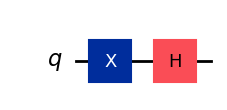

In [45]:
# circuit_to_gate wraps a circuit into a reusable gate object.
# Requires a quantum-only circuit (no classical register).
def alice_encode_pure(bit, basis):
  qc = QuantumCircuit(1)
  if bit   == 1: qc.x(0)
  if basis == 1: qc.h(0)
  return qc

# |−⟩ is the most interesting case - it uses both X and H
gate    = circuit_to_gate(alice_encode_pure(1, 1), label='Alice |−⟩')
wrapper = QuantumCircuit(1)
wrapper.append(gate, [0])
print('Encoding circuit for |−⟩ (bit=1, diagonal basis):')
display(wrapper.decompose().draw('mpl'))


bits:  {'0': 45, '1': 55}
bases: {'0': 45, '1': 55}


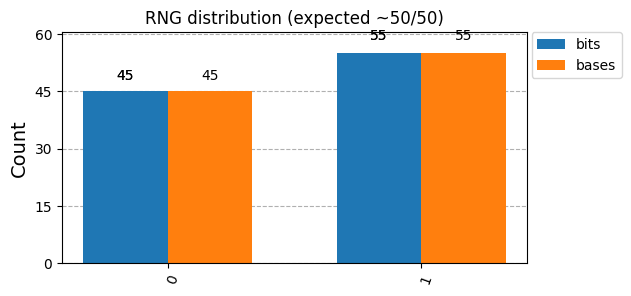

In [46]:
# Check the quantum RNG looks roughly uniform
bit_counts  = {'0': alice_bits.count(0),  '1': alice_bits.count(1)}
base_counts = {'0': alice_bases.count(0), '1': alice_bases.count(1)}
print(f'bits:  {bit_counts}')
print(f'bases: {base_counts}')
display(plot_histogram(
    [bit_counts, base_counts],
    legend=['bits', 'bases'],
    title='RNG distribution (expected ~50/50)',
    figsize=(6, 3),
))


## Bob

Bob picks a random basis for each qubit independently. If his basis matches Alice's he gets
her bit; otherwise he gets a random result.

To measure in the diagonal basis: apply H first (since H maps $|+\rangle \to |0\rangle$
and $|-\rangle \to |1\rangle$), then do a standard measurement.


In [47]:
bob_bases = quantum_random_bits(N)

def bob_measure(qubit_circuit, basis):
  qc = qubit_circuit.copy()
  if basis == 1: qc.h(0)    # rotate diagonal basis back before measuring
  qc.measure(0, 0)
  job = simulator.run(transpile(qc, simulator), shots=1)
  return int(list(job.result().get_counts().keys())[0])

bob_results = [bob_measure(qc, basis) for qc, basis in zip(transmitted_qubits, bob_bases)]

print(f'Bob bases   (first 20): {bob_bases[:20]}')
print(f'Bob results (first 20): {bob_results[:20]}')


Bob bases   (first 20): [1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1]
Bob results (first 20): [0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1]


## Sifting

Alice and Bob announce their bases publicly. They keep only the positions where they used
the same basis - about half on average. Bit values are never revealed at this stage.


In [48]:
alice_sifted = []
bob_sifted   = []

for i in range(N):
  if alice_bases[i] == bob_bases[i]:
    alice_sifted.append(alice_bits[i])
    bob_sifted.append(bob_results[i])

sifted_len = len(alice_sifted)
print(f'Kept {sifted_len}/{N} bits ({100*sifted_len/N:.0f}%) after sifting')
print(f'Alice (first 20): {alice_sifted[:20]}')
print(f'Bob   (first 20): {bob_sifted[:20]}')


Kept 50/100 bits (50%) after sifting
Alice (first 20): [0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1]
Bob   (first 20): [0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1]


## Error checking (QBER)

Alice and Bob reveal a portion of their sifted key and count mismatches.

$$\text{QBER} = \frac{\text{mismatched check bits}}{\text{total check bits}}$$

No attacker → QBER ≈ 0%.  Full intercept-resend attack → QBER ≈ 25%.  
I use a 15% threshold - sits comfortably between the two.


In [49]:
QBER_THRESHOLD = 0.15
CHECK_FRACTION = 0.25

check_size = max(1, int(sifted_len * CHECK_FRACTION))
alice_check = alice_sifted[:check_size]
bob_check = bob_sifted[:check_size]
alice_key = alice_sifted[check_size:]
bob_key = bob_sifted[check_size:]

errors = sum(a != b for a, b in zip(alice_check, bob_check))
qber = errors / check_size

print(f'Check: {check_size} bits  |  errors: {errors}  |  QBER: {qber:.1%}  |  threshold: {QBER_THRESHOLD:.0%}')


Check: 12 bits  |  errors: 0  |  QBER: 0.0%  |  threshold: 15%


## Result

### One-time pad

The key produced here is used as a one-time pad — Alice XORs her message with the key
bit-by-bit, and Bob recovers it by XORing the ciphertext with the same key:

As long as the key is truly random and used only once, this is unbreakable; even with
unlimited computing power.

In [50]:
if qber > QBER_THRESHOLD:
  print(f'Possible attack - QBER {qber:.1%} exceeds threshold ({QBER_THRESHOLD:.0%}). Aborting.')
else:
  print(f'Channel looks clean - QBER {qber:.1%}')
  print(f'Shared key length : {len(alice_key)} bits')
  print(f'Alice key (first 20): {alice_key[:20]}')
  print(f'Bob key (first 20)  : {bob_key[:20]}')
  print(f'Keys match: {alice_key == bob_key}')


Channel looks clean - QBER 0.0%
Shared key length : 38 bits
Alice key (first 20): [0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0]
Bob key (first 20)  : [0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0]
Keys match: True


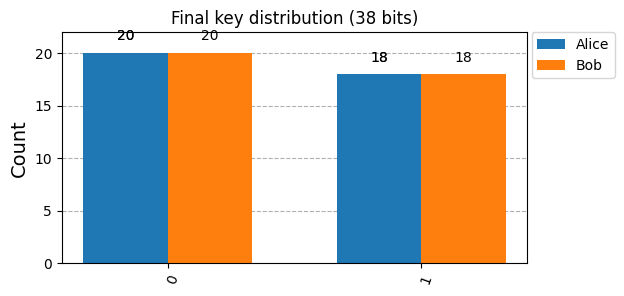

In [51]:
if qber <= QBER_THRESHOLD and len(alice_key) > 0:
    display(plot_histogram(
        [{'0': alice_key.count(0), '1': alice_key.count(1)},
         {'0': bob_key.count(0),   '1': bob_key.count(1)}],
        legend=['Alice', 'Bob'],
        title=f'Final key distribution ({len(alice_key)} bits)',
        figsize=(6, 3),
    ))


---

## Conclusion

BB84 successfully distributed a shared secret key between Alice and Bob with zero errors.
The key is ready to use as a one-time pad. Neither party ever transmitted the key itself. Only qubits and basis choices, which reveals nothing to an eavesdropper.